In [2]:
from numpy._core.fromnumeric import shape
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# load database
df = pd.read_csv("/content/population-with-un-projections.csv")
#basic onformation
print("\n shape:")
print(df.shape)

print("\n Columns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\n Missing Values:")
print(df.isnull().sum())




 shape:
(39562, 5)

 Columns:
Index(['Entity', 'Code', 'Year', 'Population', 'Population (Projected)'], dtype='object')

Data Types:
Entity                     object
Code                       object
Year                        int64
Population                float64
Population (Projected)    float64
dtype: object

 Missing Values:
Entity                        0
Code                       1208
Year                          0
Population                20174
Population (Projected)    19388
dtype: int64


In [7]:
# summery Statistics
print("\n Summery Stastics:")
print(df.describe(include="all"))

#rename population column
population_col = df.columns[-1]
df.rename(columns={population_col: "population"},inplace=True)
# latest year date
latest_year = df["Year"].max()
lateat = df[df["Year"] == latest_year]
top10 = lateat.sort_values("population",ascending = False).head(10)
print("\nTop 10 countries")
print(top10[["Entity","population"]])


 Summery Stastics:
          Entity   Code         Year    Population    population
count      39562  38354  39562.00000  1.938800e+04  2.017400e+04
unique       262    254          NaN           NaN           NaN
top     Zimbabwe    AFG          NaN           NaN           NaN
freq         151    151          NaN           NaN           NaN
mean         NaN    NaN   2025.00000  1.471637e+08  2.920943e+08
std          NaN    NaN     43.58954  6.263594e+08  1.162935e+09
min          NaN    NaN   1950.00000  5.010000e+02  5.070000e+02
25%          NaN    NaN   1987.00000  3.128385e+05  6.558880e+05
50%          NaN    NaN   2025.00000  4.156860e+06  8.881570e+06
75%          NaN    NaN   2063.00000  2.016874e+07  5.166176e+07
max          NaN    NaN   2100.00000  8.091735e+09  1.028932e+10

Top 10 countries
                                                  Entity    population
39108                                              World  1.018016e+10
19629                             Less d

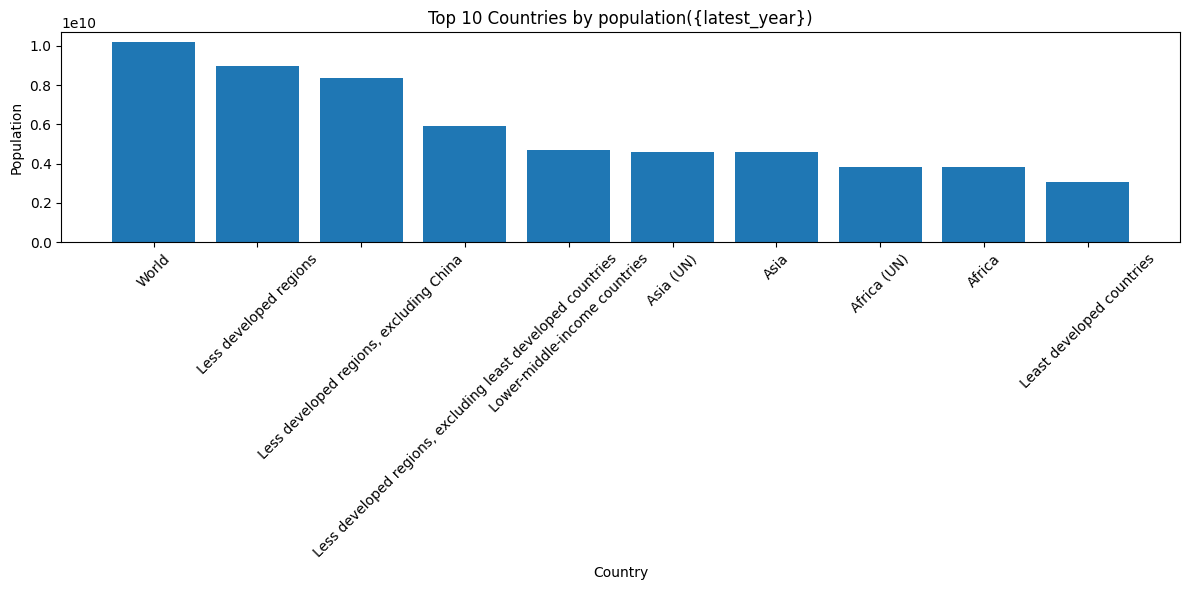

In [8]:
# graph 1
# top 10 population
plt.figure(figsize=(12,6))
plt.bar(
    top10["Entity"],
    top10["population"]
)

plt.xticks(rotation = 45)
plt.title("Top 10 Countries by population({latest_year})")
plt.xlabel("Country")
plt.ylabel("Population")

plt.tight_layout()
plt.show()


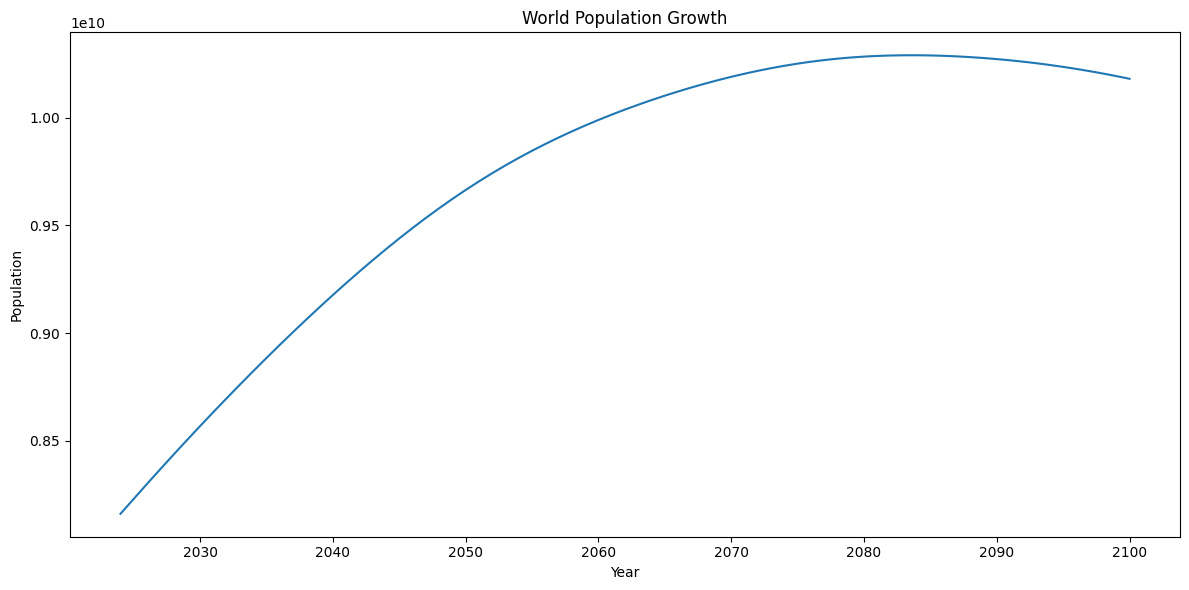

In [9]:
# Graph 2
# world population Trend
world= df[df["Entity"]== "World"]
plt.figure(figsize=(12,6))
plt.plot(
    world["Year"],
    world["population"]
)

plt.title("World Population Growth")
plt.xlabel("Year")
plt.ylabel("Population")

plt.tight_layout()
plt.show()


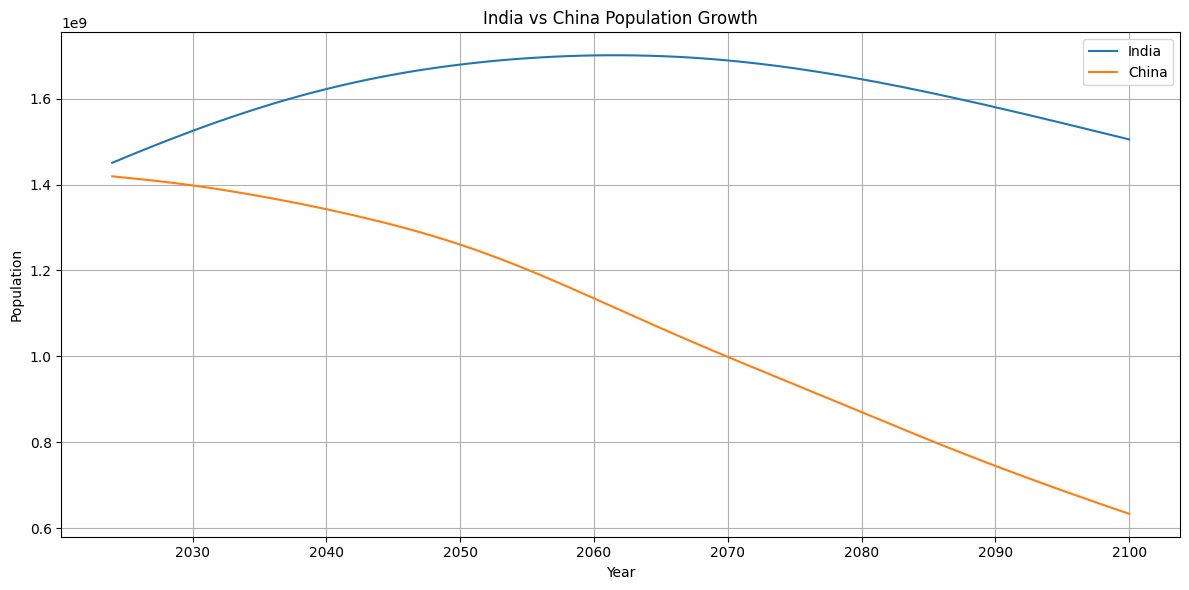

In [13]:
# Graph 3
# India vs China Population Growth

comparison = df[df["Entity"].isin(["India", "China"])]

plt.figure(figsize=(12, 6))

for country in ["India", "China"]:

    data = comparison[comparison["Entity"] == country]

    plt.plot(
        data["Year"],
        data["population"],
        label=country
    )

plt.title("India vs China Population Growth")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# growth calculation
growth =[]
for country in df["Entity"].unique():
  temp = df[df["Entity"] == country]
  if len(temp)>1:
    start = temp.iloc[0] ["population"]
    end = temp.iloc[-1] ["population"]
    growth.append([
        country,
        end-start,
    ])
    growth_df = pd.DataFrame(
    growth,
    columns=["Country","Population Growth"]
)

growth_df = growth_df.sort_values(
    "Population Growth",
    ascending=False
)

print("\nHighest Population Growth")
print(growth_df.head(10))



Highest Population Growth
          Country  Population Growth
0     Afghanistan                NaN
1          Africa                NaN
2     Africa (UN)                NaN
3         Albania                NaN
4         Algeria                NaN
5  American Samoa                NaN
6   Americas (UN)                NaN
7         Andorra                NaN
8          Angola                NaN
9        Anguilla                NaN


In [15]:
# Save Clean Dataset
df.to_excel(
    "Cleaned_Population_Data.xlsx",
    index=False
)

growth_df.to_excel(
    "Population_Growth.xlsx",
    index=False
)

print("\nAnalysis Completed Successfully.")



Analysis Completed Successfully.
